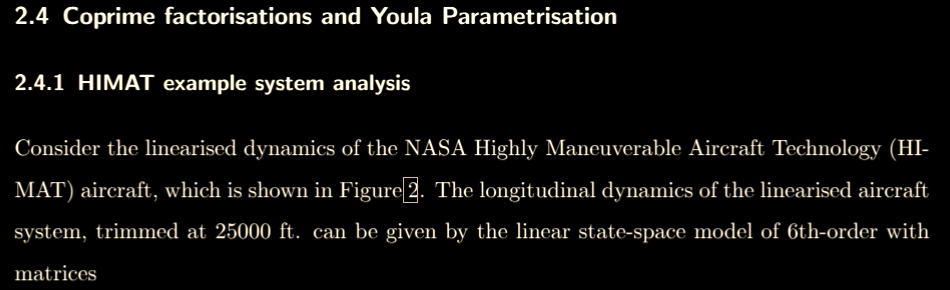

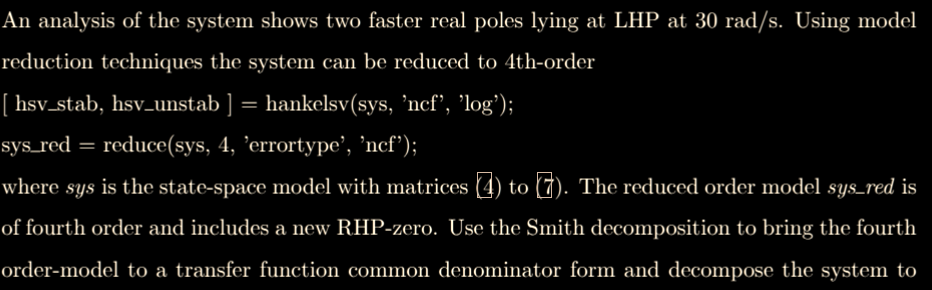

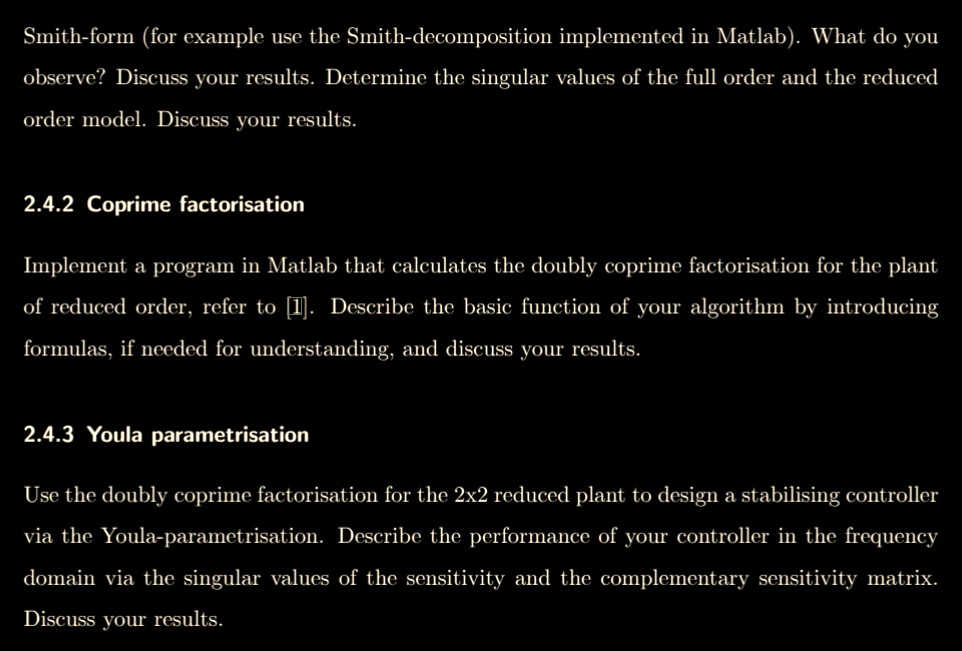

In [2]:
clear all;

% Set-up system state-space matrices
ag = [-2.2567e-02  -3.6617e+01  -1.8897e+01  -3.2090e+01   3.2509e+00  -7.6257e-01
       9.2572e-05  -1.8997e+00   9.8312e-01  -7.2562e-04  -1.7080e-01  -4.9652e-03
       1.2338e-02   1.1720e+01  -2.6316e+00   8.7582e-04  -3.1604e+01   2.2396e+01
       0            0   1.0000e+00            0            0            0 
       0            0            0            0  -3.0000e+01            0 
       0            0            0            0            0  -3.0000e+01];
bg = [0     0 
      0     0 
      0     0 
      0     0 
     30     0 
      0    30];
cg = [0     1     0     0     0     0 
      0     0     0     1     0     0];
dg = [0     0 
      0     0];
sys = ss(ag, bg, cg, dg);

In [3]:
% Reduce model order
[hsv_stab, hsv_unstab] = hankelsv(sys, 'ncf', 'log'); % Small value correspond to states that do not contribute much to future state trajectory
sys_red = reduce(sys, 4, 'errortype', 'ncf'); % Reduce model to 4th-order

% Rearrange to zpk-form
sys_zpk = zpk(sys_red);
[z, p, k] = zpkdata(sys_zpk);


In [9]:
% Set up polynomial matrix
z{1} = round(z{1}*100)/100;
z{2} = round(z{2}*100)/100;
z{3} = round(z{3}*100)/100;
z{4} = round(z{4}*100)/100;
k1   = round(k*100)/100;
syms t
N = [k1(1,1)*(t - z{1}(1))*(t - z{1}(2))*(t - z{1}(3)) k1(1,2)*(t - z{3}(1))*(t - z{3}(2))*(t - z{3}(3))
     k1(2,1)*(t - z{2}(1))*(t - z{2}(2))*(t - z{2}(3)) k1(2,2)*(t - z{4}(1))*(t - z{4}(2))*(t - z{4}(3))];
 
% Rearrange matrix to Smith form
A = N; % Note that this is a transfer function matrix

In [10]:
% Get transfer function matrix data for the reduced system
n1 = conv([1 -z{1}(1)], [1 -z{1}(2)]);
n11 = k(1,1)*conv([1 -z{1}(3)], n1); 

n1 = conv([1 -z{3}(1)], [1 -z{3}(2)]);
n12 = k(1,2)*conv([1 -z{3}(3)], n1); 

n1 = conv([1 -z{2}(1)], [1 -z{2}(2)]);
n21 = k(2,1)*conv([1 -z{2}(3)], n1);

n1 = conv([1 -z{4}(1)], [1 -z{4}(2)]);
n22 = k(2,2)*conv([1 -z{4}(3)], n1); 

% Get Smith-form for matrices of decomposed poynomial coefficients
N1 = [n11(1) n12(1); n21(1) n22(1)];

In [11]:
N1

N1 = 2×2 double
    0.3384   -0.3349
    0.4755   -0.3107

Implement a program in Matlab that calculates the doubly coprime factorisation for the plant
of reduced order, refer to [1]. Describe the basic function of your algorithm by introducing
formulas, if needed for understanding, and discuss your results

Not enough input arguments.

Error in place (line 33)
[nx,na] = size(A);
^^^^^^^^^^^^^^^^^^